# BrechApp Analysis (Big Data Edition)

This notebook analyzes the historical exchange rate gap using **Polars** and **Parquet**.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load Parquet Data
processed_dir = os.path.join('..', 'data', 'processed')
parquet_path = os.path.join(processed_dir, 'history.parquet')

df = pl.read_parquet(parquet_path)
print(df.schema)
df.head()

Schema({'casa': String, 'compra': Float64, 'venta': Float64, 'fecha': Date})


casa,compra,venta,fecha
str,f64,f64,date
"""blue""",4.0,4.0,2011-01-03
"""blue""",4.0,4.0,2011-01-04
"""blue""",4.0,4.0,2011-01-05
"""blue""",4.0,4.0,2011-01-06
"""blue""",4.0,4.0,2011-01-07


## Data Transformation
We need to pivot the data to have columns for each 'casa' (oficial, blue, etc.) to calculate the gap.

In [2]:
# Pivot to get columns: fecha, oficial_venta, blue_venta, etc.
# We filter for 'venta' price usually for gap calculation

df_pivot = df.pivot(
    values="venta",
    index="fecha",
    columns="casa",
    aggregate_function="first"
).sort("fecha")

df_pivot.head()

C:\Users\davos\AppData\Local\Temp\ipykernel_25096\2861840260.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_pivot = df.pivot(


fecha,blue,contadoconliqui,mayorista,oficial
date,f64,f64,f64,f64
2011-01-03,4.0,null,3.98,4.0
2011-01-04,4.0,null,3.98,4.0
2011-01-05,4.0,null,3.98,4.0
2011-01-06,4.0,null,3.98,4.0
2011-01-07,4.0,null,3.98,4.0


## Gap Calculation
Calculate the gap (brecha) between Blue and Oficial.

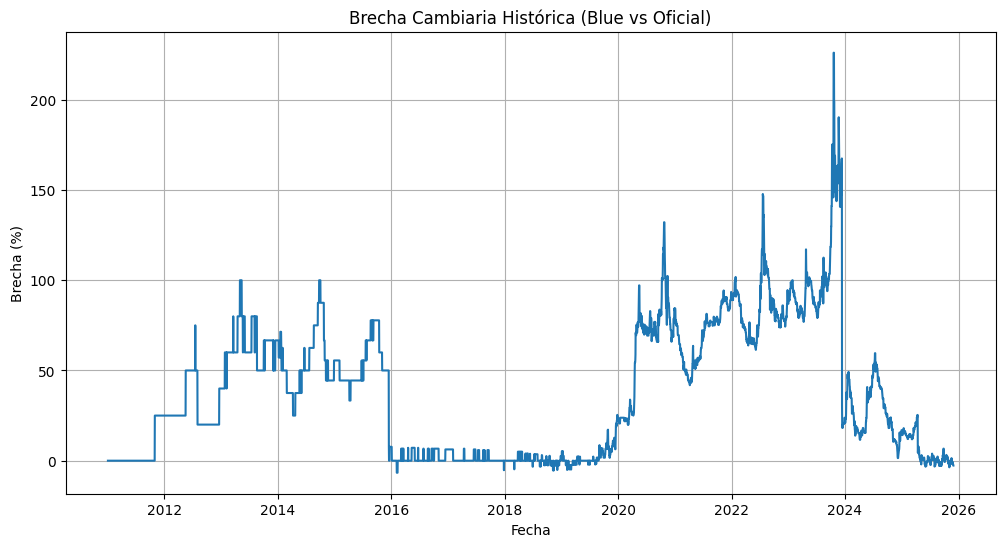

In [3]:
if "blue" in df_pivot.columns and "oficial" in df_pivot.columns:
    df_pivot = df_pivot.with_columns(
        ((pl.col("blue") - pl.col("oficial")) / pl.col("oficial") * 100).alias("brecha_blue")
    )
    
    # Plotting
    # Convert to pandas for plotting with Seaborn/Matplotlib
    pdf = df_pivot.select(["fecha", "brecha_blue"]).drop_nulls().to_pandas()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=pdf, x="fecha", y="brecha_blue")
    plt.title("Brecha Cambiaria Histórica (Blue vs Oficial)")
    plt.ylabel("Brecha (%)")
    plt.xlabel("Fecha")
    plt.grid(True)
    plt.show()
else:
    print("Blue or Oficial data missing")